# Advanced Analytics & Risk Metrics

## Capstone Project I - Mutual Fund Analytics

**Prepared by:** Ashutosh Giri

### Objectives
- Historical VaR (95%) & CVaR
- Rolling 90-Day Sharpe Ratio
- Investor Cohort Analysis
- SIP Continuity Analysis
- Fund Recommendation System
- Sector HHI Concentration
- Business Insights

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [4]:
nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")
performance = pd.read_csv("../data/processed/07_scheme_performance_cleaned.csv")
transactions = pd.read_csv("../data/processed/08_investor_transactions_cleaned.csv")

In [5]:
print(nav.shape)
print(performance.shape)
print(transactions.shape)

(46000, 3)
(40, 19)
(32778, 13)


In [6]:
print("NAV Dataset Shape:", nav.shape)
print("\nColumns:")
print(nav.columns)

nav.head()

NAV Dataset Shape: (46000, 3)

Columns:
Index(['amfi_code', 'date', 'nav'], dtype='object')


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [7]:
nav["date"] = pd.to_datetime(nav["date"])

# Sort data
nav = nav.sort_values(["amfi_code", "date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [8]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [9]:
print(nav["daily_return"].isna().sum())

40


In [10]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [11]:
def calculate_var_cvar(returns):

    returns = returns.dropna()

    if len(returns) == 0:
        return pd.Series({
            "VaR_95": np.nan,
            "CVaR_95": np.nan
        })

    var95 = np.percentile(returns, 5)

    cvar95 = returns[returns <= var95].mean()

    return pd.Series({
        "VaR_95": var95,
        "CVaR_95": cvar95
    })

In [12]:
risk_metrics = (
    nav.groupby("amfi_code")["daily_return"]
       .apply(calculate_var_cvar)
       .reset_index()
)

risk_metrics.head()

,amfi_code,level_1,daily_return
0,100016,VaR_95,-0.014364
1,100016,CVaR_95,-0.018060
2,100025,VaR_95,-0.003793
3,100025,CVaR_95,-0.004994
4,100033,VaR_95,-0.019034


In [13]:
risk_metrics = risk_metrics.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

risk_metrics.head()

,amfi_code,level_1,daily_return,scheme_name
0,100016,VaR_95,-0.014364,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,CVaR_95,-0.018060,HDFC Top 100 Fund - Regular Plan - Growth
2,100025,VaR_95,-0.003793,HDFC Short Term Debt Fund - Regular - Growth
3,100025,CVaR_95,-0.004994,HDFC Short Term Debt Fund - Regular - Growth
4,100033,VaR_95,-0.019034,HDFC Mid-Cap Opportunities Fund - Regular - Gr...


In [17]:
risk_metrics = risk_metrics.pivot(
    index=["amfi_code", "scheme_name"],
    columns="level_1",
    values="daily_return"
).reset_index()

risk_metrics.head()

level_1,amfi_code,scheme_name,CVaR_95,VaR_95
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.018060,-0.014364
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.004994,-0.003793
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.023456,-0.019034
3,101206,ABSL Frontline Equity Fund - Regular - Growth,-0.017439,-0.013282
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.032459,-0.026021


In [18]:
risk_metrics.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

print("var_cvar_report.csv saved successfully!")

var_cvar_report.csv saved successfully!


## Task 2: Rolling 90-Day Sharpe Ratio

In [19]:
nav["rolling_mean"] = (
    nav.groupby("amfi_code")["daily_return"]
       .transform(lambda x: x.rolling(window=90).mean())
)

nav["rolling_std"] = (
    nav.groupby("amfi_code")["daily_return"]
       .transform(lambda x: x.rolling(window=90).std())
)

nav["rolling_sharpe"] = (
    nav["rolling_mean"] / nav["rolling_std"]
) * np.sqrt(252)

nav.head()

,amfi_code,date,nav,daily_return,rolling_mean,rolling_std,rolling_sharpe
0,100016,2022-01-03,520.4608,NaN,NaN,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,NaN,NaN,NaN
2,100016,2022-01-05,521.7239,0.012865,NaN,NaN,NaN
3,100016,2022-01-06,515.7880,-0.011377,NaN,NaN,NaN
4,100016,2022-01-07,515.1639,-0.001210,NaN,NaN,NaN


In [20]:
performance[["amfi_code", "scheme_name"]].head(10)

,amfi_code,scheme_name
0,119551,SBI Bluechip Fund - Regular Plan - Growth
1,119552,SBI Bluechip Fund - Direct Plan - Growth
2,119598,SBI Small Cap Fund - Regular Plan - Growth
3,119599,SBI Small Cap Fund - Direct Plan - Growth
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth
5,100016,HDFC Top 100 Fund - Regular Plan - Growth
6,125497,HDFC Top 100 Fund - Direct Plan - Growth
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
8,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth
9,100025,HDFC Short Term Debt Fund - Regular - Growth


In [21]:
selected_funds = [119551, 100016, 100033, 100025, 119598]

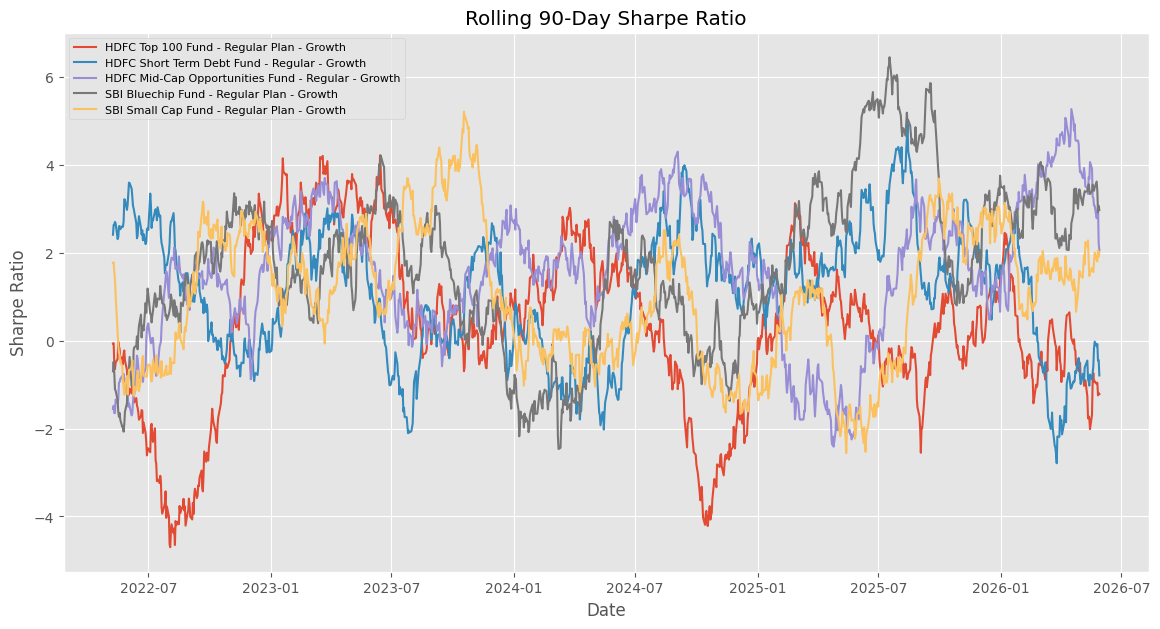

In [22]:
plot_data = nav[nav["amfi_code"].isin(selected_funds)]

# Add scheme names
plot_data = plot_data.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

plt.figure(figsize=(14,7))

for scheme in plot_data["scheme_name"].unique():
    temp = plot_data[plot_data["scheme_name"] == scheme]
    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=scheme
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend(fontsize=8)
plt.grid(True)

plt.savefig("../reports/rolling_sharpe_chart.png", dpi=300)
plt.show()

## Task 3: Investor Cohort Analysis

In [23]:
transactions.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')

In [24]:
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [26]:
transactions = transactions.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,scheme_name_x,scheme_name_y
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,Axis Bluechip Fund - Regular - Growth,Axis Bluechip Fund - Regular - Growth
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset Large Cap Fund - Regular - Growth
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,Nippon India Gilt Securities Fund - Regular - ...,Nippon India Gilt Securities Fund - Regular - ...
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,Nippon India Small Cap Fund - Regular - Growth,Nippon India Small Cap Fund - Regular - Growth
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,Axis Midcap Fund - Regular - Growth,Axis Midcap Fund - Regular - Growth


In [27]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

# First transaction year for each investor
first_txn = (
    transactions.groupby("investor_id")["transaction_date"]
    .min()
    .dt.year
    .reset_index(name="cohort_year")
)

# Merge back
transactions = transactions.merge(
    first_txn,
    on="investor_id",
    how="left"
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,scheme_name_x,scheme_name_y,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,Axis Bluechip Fund - Regular - Growth,Axis Bluechip Fund - Regular - Growth,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset Large Cap Fund - Regular - Growth,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,Nippon India Gilt Securities Fund - Regular - ...,Nippon India Gilt Securities Fund - Regular - ...,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,Nippon India Small Cap Fund - Regular - Growth,Nippon India Small Cap Fund - Regular - Growth,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,Axis Midcap Fund - Regular - Growth,Axis Midcap Fund - Regular - Growth,2024


In [28]:
cohort_summary = (
    transactions.groupby("cohort_year")
    .agg(
        avg_sip_amount=("amount_inr", "mean"),
        total_invested=("amount_inr", "sum"),
        total_transactions=("investor_id", "count"),
        unique_investors=("investor_id", "nunique")
    )
    .reset_index()
)

cohort_summary

,cohort_year,avg_sip_amount,total_invested,total_transactions,unique_investors
0,2024,107422.541832,3491125187,32499,4803
1,2025,109158.577061,30455243,279,197


In [30]:
transactions = transactions.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

transactions[["amfi_code", "scheme_name"]].head()

,amfi_code,scheme_name
0,119092,Axis Bluechip Fund - Regular - Growth
1,148567,Mirae Asset Large Cap Fund - Regular - Growth
2,118636,Nippon India Gilt Securities Fund - Regular - ...
3,118634,Nippon India Small Cap Fund - Regular - Growth
4,119094,Axis Midcap Fund - Regular - Growth


In [31]:
top_funds = (
    transactions.groupby(["cohort_year", "scheme_name"])
    .size()
    .reset_index(name="count")
)

top_funds = (
    top_funds.sort_values(
        ["cohort_year", "count"],
        ascending=[True, False]
    )
    .groupby("cohort_year")
    .first()
    .reset_index()
)

top_funds

,cohort_year,scheme_name,count
0,2024,Mirae Asset Emerging Bluechip Fund - Regular -...,874
1,2025,ICICI Pru Liquid Fund - Regular - Growth,12


In [32]:
cohort_report = cohort_summary.merge(
    top_funds[["cohort_year", "scheme_name"]],
    on="cohort_year",
    how="left"
)

cohort_report.rename(
    columns={
        "scheme_name": "top_fund_preference"
    },
    inplace=True
)

cohort_report

,cohort_year,avg_sip_amount,total_invested,total_transactions,unique_investors,top_fund_preference
0,2024,107422.541832,3491125187,32499,4803,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,109158.577061,30455243,279,197,ICICI Pru Liquid Fund - Regular - Growth


In [33]:
cohort_report.to_csv(
    "../reports/cohort_analysis.csv",
    index=False
)

print("cohort_analysis.csv saved successfully!")

cohort_analysis.csv saved successfully!


### Observation

- The majority of investors belong to the 2024 cohort.
- The 2024 cohort has significantly higher total investment than the 2025 cohort.
- The most preferred mutual fund differs across cohorts based on transaction frequency.

## Task 4: SIP Continuity Analysis

In [35]:
sip = transactions[
    transactions["transaction_type"] == "SIP"
].copy()

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,scheme_name_x,scheme_name_y,cohort_year,scheme_name
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,Axis Bluechip Fund - Regular - Growth,Axis Bluechip Fund - Regular - Growth,2024,Axis Bluechip Fund - Regular - Growth
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,Nippon India Gilt Securities Fund - Regular - ...,Nippon India Gilt Securities Fund - Regular - ...,2024,Nippon India Gilt Securities Fund - Regular - ...
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,Nippon India Small Cap Fund - Regular - Growth,Nippon India Small Cap Fund - Regular - Growth,2024,Nippon India Small Cap Fund - Regular - Growth
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,ABSL Liquid Fund - Regular - Growth,ABSL Liquid Fund - Regular - Growth,2024,ABSL Liquid Fund - Regular - Growth
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified,ABSL Liquid Fund - Regular - Growth,ABSL Liquid Fund - Regular - Growth,2024,ABSL Liquid Fund - Regular - Growth


In [36]:
sip["transaction_date"] = pd.to_datetime(
    sip["transaction_date"]
)

sip = sip.sort_values(
    ["investor_id", "transaction_date"]
)

In [37]:
sip["gap_days"] = (
    sip.groupby("investor_id")["transaction_date"]
       .diff()
       .dt.days
)

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,scheme_name_x,scheme_name_y,cohort_year,scheme_name,gap_days
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,ICICI Pru Midcap Fund - Regular - Growth,ICICI Pru Midcap Fund - Regular - Growth,2024,ICICI Pru Midcap Fund - Regular - Growth,NaN
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,HDFC Top 100 Fund - Direct Plan - Growth,HDFC Top 100 Fund - Direct Plan - Growth,2024,HDFC Top 100 Fund - Direct Plan - Growth,76.0
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,DSP Top 100 Equity Fund - Regular - Growth,DSP Top 100 Equity Fund - Regular - Growth,2024,DSP Top 100 Equity Fund - Regular - Growth,NaN
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,Kotak Bluechip Fund - Regular - Growth,Kotak Bluechip Fund - Regular - Growth,2024,Kotak Bluechip Fund - Regular - Growth,176.0
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,Axis Midcap Fund - Regular - Growth,Axis Midcap Fund - Regular - Growth,2024,Axis Midcap Fund - Regular - Growth,238.0


In [38]:
sip_summary = (
    sip.groupby("investor_id")
       .agg(
           sip_count=("transaction_date", "count"),
           avg_gap_days=("gap_days", "mean")
       )
       .reset_index()
)

sip_summary = sip_summary[
    sip_summary["sip_count"] >= 6
]

sip_summary.head()

,investor_id,sip_count,avg_gap_days
3,INV000004,6,85.400000
7,INV000008,6,70.400000
9,INV000010,6,64.800000
10,INV000011,7,40.166667
11,INV000012,8,57.000000


In [39]:
sip_summary["risk_status"] = np.where(
    sip_summary["avg_gap_days"] > 35,
    "At Risk",
    "Healthy"
)

sip_summary.head()

,investor_id,sip_count,avg_gap_days,risk_status
3,INV000004,6,85.400000,At Risk
7,INV000008,6,70.400000,At Risk
9,INV000010,6,64.800000,At Risk
10,INV000011,7,40.166667,At Risk
11,INV000012,8,57.000000,At Risk


In [40]:
sip_summary.to_csv(
    "../reports/sip_continuity_analysis.csv",
    index=False
)

print("✅ sip_continuity_analysis.csv saved successfully!")

✅ sip_continuity_analysis.csv saved successfully!


### Observation

- Investors with an average SIP gap greater than 35 days are classified as **At Risk**.
- Investors maintaining regular SIP intervals are marked as **Healthy**.
- This analysis helps identify investors who may discontinue systematic investments.

## Task 6: Sector HHI Concentration Analysis

In [41]:
import os

print(os.listdir("../data/processed"))

['02_nav_history_cleaned.csv', '07_scheme_performance_cleaned.csv', '08_investor_transactions_cleaned.csv', 'aum_dashboard.csv', 'benchmark_dashboard.csv', 'category_dashboard.csv', 'folio_dashboard.csv', 'nav_dashboard.csv', 'performance_dashboard.csv', 'portfolio_dashboard.csv', 'sip_dashboard.csv', 'transaction_dashboard.csv']


In [42]:
for file in os.listdir("../data/processed"):
    print(file)

02_nav_history_cleaned.csv
07_scheme_performance_cleaned.csv
08_investor_transactions_cleaned.csv
aum_dashboard.csv
benchmark_dashboard.csv
category_dashboard.csv
folio_dashboard.csv
nav_dashboard.csv
performance_dashboard.csv
portfolio_dashboard.csv
sip_dashboard.csv
transaction_dashboard.csv


In [43]:
portfolio = pd.read_csv("../data/processed/portfolio_dashboard.csv")

print(portfolio.columns)

portfolio.head()

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


### Calculate Herfindahl-Hirschman Index (HHI)


In [44]:
portfolio["weight_decimal"] = portfolio["weight_pct"] / 100

portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date,weight_decimal
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31,0.1385
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31,0.1119
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31,0.0990
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31,0.0476
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31,0.1025


In [45]:
hhi = (
    portfolio.groupby("amfi_code")
    .apply(lambda x: (x["weight_decimal"] ** 2).sum())
    .reset_index(name="HHI")
)

hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [46]:
hhi = hhi.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

hhi.head()

,amfi_code,HHI,scheme_name
0,100016,0.139534,HDFC Top 100 Fund - Regular Plan - Growth
1,100033,0.147592,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2,101206,0.129332,ABSL Frontline Equity Fund - Regular - Growth
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth


In [47]:
def classify_hhi(value):

    if value < 0.15:
        return "Highly Diversified"

    elif value < 0.25:
        return "Moderately Concentrated"

    else:
        return "Highly Concentrated"


hhi["Portfolio_Type"] = hhi["HHI"].apply(classify_hhi)

hhi.head()

,amfi_code,HHI,scheme_name,Portfolio_Type
0,100016,0.139534,HDFC Top 100 Fund - Regular Plan - Growth,Highly Diversified
1,100033,0.147592,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Highly Diversified
2,101206,0.129332,ABSL Frontline Equity Fund - Regular - Growth,Highly Diversified
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Moderately Concentrated
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,Moderately Concentrated


In [48]:
hhi = hhi.sort_values(
    by="HHI",
    ascending=False
)

hhi.head(10)

,amfi_code,HHI,scheme_name,Portfolio_Type
11,119092,0.206448,Axis Bluechip Fund - Regular - Growth,Moderately Concentrated
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Moderately Concentrated
18,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth,Moderately Concentrated
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,Moderately Concentrated
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth,Moderately Concentrated
29,148568,0.167930,Mirae Asset Emerging Bluechip Fund - Regular -...,Moderately Concentrated
21,120505,0.157570,ICICI Pru Midcap Fund - Regular - Growth,Moderately Concentrated
22,120506,0.153794,ICICI Pru Value Discovery Fund - Regular - Growth,Moderately Concentrated
27,125498,0.152414,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Moderately Concentrated
23,120841,0.149680,Kotak Bluechip Fund - Regular - Growth,Highly Diversified


In [49]:
hhi.to_csv(
    "../reports/sector_hhi_analysis.csv",
    index=False
)

print("sector_hhi_analysis.csv saved successfully!")

sector_hhi_analysis.csv saved successfully!


### Observation

- Higher HHI indicates a more concentrated portfolio.
- Lower HHI represents better diversification across sectors.
- Highly concentrated portfolios may offer higher returns but carry greater risk.
- Diversified portfolios help reduce sector-specific risk.

# Final Business Insights

1. Historical VaR and CVaR identified the mutual funds with the highest downside risk.

2. Rolling 90-Day Sharpe Ratio highlighted funds that consistently delivered better risk-adjusted returns over time.

3. Investor Cohort Analysis revealed that the 2024 investor cohort contributed the highest investment and transaction volume.

4. SIP Continuity Analysis identified investors at risk of discontinuing SIPs based on average transaction gaps greater than 35 days.

5. Sector HHI Analysis showed which mutual fund portfolios are highly diversified and which are more concentrated, helping investors better understand concentration risk.

# Conclusion

This project successfully applied financial analytics techniques to evaluate mutual fund performance, investor behaviour, portfolio concentration, and risk metrics. The analysis provides actionable insights for investors, fund managers, and financial analysts using Python, Pandas, NumPy, and data visualization techniques.